# 04 - Temporal Split

Este notebook define a estrutura de avaliacao. Nenhuma feature nova, nenhum modelo.
Nao sobrescreve `loans_clean.parquet`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'

EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

df = pd.read_parquet(PROCESSED_DIR / 'loans_clean.parquet')
print(f'Shape carregado: {df.shape}')
assert df.shape == (673314, 84), f'Shape inesperado: {df.shape}'


Shape carregado: (673314, 84)


## Secao 1 - Recorte de prazo

term = 36 meses vira a populacao principal (treino/validacao/teste). term = 60 meses vira
um conjunto de transferencia (holdout de prazo), guardado intocado para testar
generalizacao entre prazos depois que um modelo for escolhido.

In [2]:
main_pop = df.loc[df['term'] == 36].copy()
transfer_60m = df.loc[df['term'] == 60].copy()

print(f'Populacao principal (36m): N={len(main_pop):,} | taxa de default={main_pop["target"].mean() * 100:.4f}%')
print(f'Conjunto de transferencia (60m): N={len(transfer_60m):,} | taxa de default={transfer_60m["target"].mean() * 100:.4f}%')
print(f'N principal + N transferencia = {len(main_pop) + len(transfer_60m):,} (deve bater com {len(df):,})')
assert len(main_pop) + len(transfer_60m) == len(df)


Populacao principal (36m): N=618,345 | taxa de default=13.8939%
Conjunto de transferencia (60m): N=54,969 | taxa de default=25.1596%
N principal + N transferencia = 673,314 (deve bater com 673,314)


In [3]:
term_unico = main_pop['term'].nunique() == 1
print(f'term e constante na populacao principal? {term_unico} -> valor: {sorted(main_pop["term"].unique())}')
print('term fica de fora do conjunto de features a partir daqui (ja e EVAL_ONLY), mas permanece')
print('no parquet - necessaria para o calculo de resultado financeiro (installment * term - loan_amnt).')


term e constante na populacao principal? True -> valor: [np.float64(36.0)]
term fica de fora do conjunto de features a partir daqui (ja e EVAL_ONLY), mas permanece
no parquet - necessaria para o calculo de resultado financeiro (installment * term - loan_amnt).


## Secao 2 - Split temporal da populacao principal (36 meses)

- Treino: issue_d <= 2013-12-31
- Validacao: issue_d em 2014
- Teste: issue_d em 2015

In [4]:
TRAIN_END = pd.Timestamp('2013-12-31')
VAL_START = pd.Timestamp('2014-01-01')
VAL_END = pd.Timestamp('2014-12-31')
TEST_START = pd.Timestamp('2015-01-01')
TEST_END = pd.Timestamp('2015-12-31')

train = main_pop.loc[main_pop['issue_d'] <= TRAIN_END]
validation = main_pop.loc[(main_pop['issue_d'] >= VAL_START) & (main_pop['issue_d'] <= VAL_END)]
test = main_pop.loc[(main_pop['issue_d'] >= TEST_START) & (main_pop['issue_d'] <= TEST_END)]

splits = {'train': train, 'validation': validation, 'test': test}
n_total_main = len(main_pop)

rows = []
for name, d in splits.items():
    rows.append({
        'conjunto': name,
        'N': len(d),
        '%_do_total': round(len(d) / n_total_main * 100, 2),
        'taxa_default_%': round(d['target'].mean() * 100, 4),
        'issue_d_min': d['issue_d'].min(),
        'issue_d_max': d['issue_d'].max(),
        'era_pre_2012_soma': int(d['era_pre_2012'].sum()),
    })

split_summary = pd.DataFrame(rows).set_index('conjunto')
split_summary


,N,%_do_total,taxa_default_%,issue_d_min,issue_d_max,era_pre_2012_soma
conjunto,,,,,,
train,172988,27.98,12.4332,2007-06-01,2013-12-01,51646
validation,162570,26.29,13.7264,2014-01-01,2014-12-01,0
test,282787,45.73,14.8836,2015-01-01,2015-12-01,0


## Secao 3 - Diagnostico do split

### 1. Taxa de default por ano de issue_d dentro de cada conjunto

In [5]:
main_pop_tagged = main_pop.copy()
main_pop_tagged['ano_emissao'] = main_pop_tagged['issue_d'].dt.year

conditions = [main_pop_tagged['issue_d'] <= TRAIN_END,
              (main_pop_tagged['issue_d'] >= VAL_START) & (main_pop_tagged['issue_d'] <= VAL_END),
              (main_pop_tagged['issue_d'] >= TEST_START) & (main_pop_tagged['issue_d'] <= TEST_END)]
choices = ['train', 'validation', 'test']
main_pop_tagged['conjunto'] = np.select(conditions, choices, default='fora_do_split')

n_fora = int((main_pop_tagged['conjunto'] == 'fora_do_split').sum())
print(f'Linhas fora do split (deveria ser 0, pop. principal so vai ate dez/2015): {n_fora}')

default_by_year_conjunto = main_pop_tagged.groupby(['ano_emissao', 'conjunto'])['target'].agg(N='count', taxa_default_pct='mean')
default_by_year_conjunto['taxa_default_pct'] = (default_by_year_conjunto['taxa_default_pct'] * 100).round(2)
default_by_year_conjunto


Linhas fora do split (deveria ser 0, pop. principal so vai ate dez/2015): 0


,,N,taxa_default_pct
ano_emissao,conjunto,,
2007,train,251,17.93
2008,train,1562,15.81
2009,train,4716,12.60
2010,train,8466,9.95
2011,train,14101,10.63
2012,train,43470,13.58
2013,train,100422,12.33
2014,validation,162570,13.73
2015,test,282787,14.88


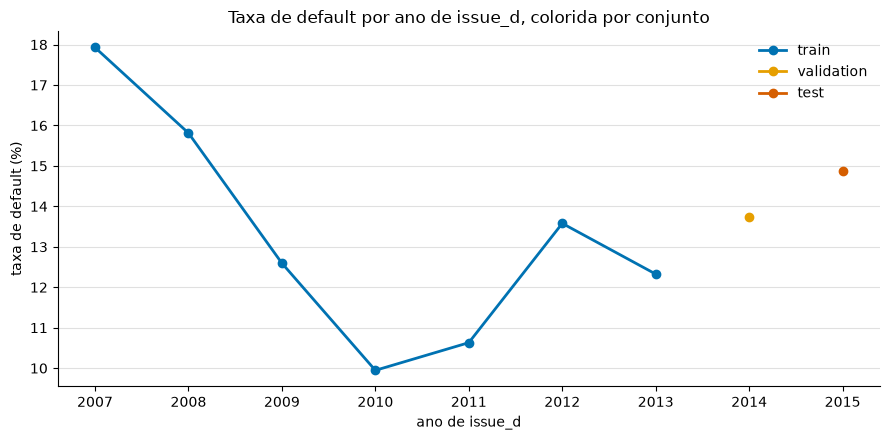

In [6]:
pivot = main_pop_tagged.pivot_table(index='ano_emissao', columns='conjunto', values='target', aggfunc='mean') * 100
colors = {'train': '#0072B2', 'validation': '#E69F00', 'test': '#D55E00'}

fig, ax = plt.subplots(figsize=(9, 4.5))
for conjunto in ['train', 'validation', 'test']:
    if conjunto in pivot.columns:
        serie = pivot[conjunto].dropna()
        ax.plot(serie.index, serie.values, marker='o', linewidth=2, color=colors[conjunto], label=conjunto)
ax.set_xlabel('ano de issue_d')
ax.set_ylabel('taxa de default (%)')
ax.set_title('Taxa de default por ano de issue_d, colorida por conjunto')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 2. Distribution shift entre treino, validacao e teste - 65 features candidatas (familia C)

In [7]:
family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']

assert len(family_C_features) == 65, f'Esperava 65 features candidatas, lista tem {len(family_C_features)}'
assert all(c in df.columns for c in family_C_features)

categorical_cols = [c for c in family_C_features if not pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_datetime64_any_dtype(df[c])]
datetime_cols = [c for c in family_C_features if pd.api.types.is_datetime64_any_dtype(df[c])]
numeric_cols = [c for c in family_C_features if pd.api.types.is_numeric_dtype(df[c])]

print(f'Numericas: {len(numeric_cols)} | Datetime: {len(datetime_cols)} | Categoricas: {len(categorical_cols)}')
print('Categoricas:', categorical_cols)
print('Datetime (SMD calculado sobre nanosegundos desde epoch - deslocamento alto e esperado para issue_d,')
print('ja que e literalmente o criterio do split):', datetime_cols)


Numericas: 58 | Datetime: 2 | Categoricas: 5
Categoricas: ['home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type']
Datetime (SMD calculado sobre nanosegundos desde epoch - deslocamento alto e esperado para issue_d,
ja que e literalmente o criterio do split): ['issue_d', 'earliest_cr_line']


In [8]:
shift_rows = []

for c in numeric_cols + datetime_cols:
    if c in datetime_cols:
        s_train = train[c].astype('int64')
        s_val = validation[c].astype('int64')
        s_test = test[c].astype('int64')
    else:
        s_train = train[c]
        s_val = validation[c]
        s_test = test[c]
    mean_train, mean_val, mean_test = s_train.mean(), s_val.mean(), s_test.mean()
    median_train, median_val, median_test = s_train.median(), s_val.median(), s_test.median()
    std_train, std_val, std_test = s_train.std(), s_val.std(), s_test.std()
    pooled_std = np.sqrt((std_train ** 2 + std_test ** 2) / 2)
    smd = abs(mean_train - mean_test) / pooled_std if pooled_std > 0 else 0.0
    shift_rows.append({
        'coluna': c, 'tipo': 'datetime' if c in datetime_cols else 'numerica',
        'tipo_metrica': 'SMD',
        'metrica_deslocamento': round(smd, 4),
        'media_treino': mean_train, 'mediana_treino': median_train, 'std_treino': std_train,
        'media_val': mean_val, 'mediana_val': median_val, 'std_val': std_val,
        'media_teste': mean_test, 'mediana_teste': median_test, 'std_teste': std_test,
    })

for c in categorical_cols:
    props_train = train[c].value_counts(normalize=True, dropna=False)
    props_test = test[c].value_counts(normalize=True, dropna=False)
    all_cats = set(props_train.index) | set(props_test.index)
    max_gap = max(abs(props_train.get(cat, 0) - props_test.get(cat, 0)) for cat in all_cats)
    shift_rows.append({
        'coluna': c, 'tipo': 'categorica',
        'tipo_metrica': 'max_gap_proporcao',
        'metrica_deslocamento': round(max_gap, 4),
        'media_treino': np.nan, 'mediana_treino': np.nan, 'std_treino': np.nan,
        'media_val': np.nan, 'mediana_val': np.nan, 'std_val': np.nan,
        'media_teste': np.nan, 'mediana_teste': np.nan, 'std_teste': np.nan,
    })

shift_df = pd.DataFrame(shift_rows).sort_values('metrica_deslocamento', ascending=False).reset_index(drop=True)
print(f'Total de features avaliadas: {len(shift_df)}')
print()
print('Top 20 por deslocamento (SMD para numericas/datetime, maior gap de proporcao para categoricas):')
shift_df.head(20)


Total de features avaliadas: 65

Top 20 por deslocamento (SMD para numericas/datetime, maior gap de proporcao para categoricas):


,coluna,tipo,tipo_metrica,metrica_deslocamento,media_treino,mediana_treino,std_treino,media_val,mediana_val,std_val,media_teste,mediana_teste,std_teste
0,issue_d,datetime,SMD,3.2511,1.350604e+15,1.362096e+15,3.586667e+13,1.403594e+15,1.404173e+15,8.665572e+12,1.435672e+15,1.435709e+15,9.105452e+12
1,num_tl_30dpd,numerica,SMD,0.9161,-2.972923e-01,0.000000e+00,4.601056e-01,3.512333e-03,0.000000e+00,6.357143e-02,3.971187e-03,0.000000e+00,6.765951e-02
2,pct_tl_nvr_dlq,numerica,SMD,0.8440,6.645951e+01,9.400000e+01,4.453482e+01,9.395275e+01,9.740000e+01,8.778486e+00,9.359917e+01,9.710000e+01,9.197660e+00
3,mo_sin_old_il_acct,numerica,SMD,0.8086,4.115550e+02,1.500000e+02,4.141135e+02,1.579900e+02,1.310000e+02,1.714698e+02,1.557428e+02,1.300000e+02,1.693145e+02
4,num_tl_120dpd_2m,numerica,SMD,0.6943,-2.994890e-01,0.000000e+00,4.587039e-01,-3.876484e-02,0.000000e+00,1.981917e-01,-4.957441e-02,0.000000e+00,2.208116e-01
5,percent_bc_gt_75,numerica,SMD,0.6891,2.514955e+02,6.670000e+01,3.867434e+02,5.974795e+01,5.000000e+01,1.068895e+02,5.618048e+01,5.000000e+01,1.053333e+02
6,bc_util,numerica,SMD,0.6876,2.624150e+02,8.100000e+01,3.810229e+02,7.403230e+01,6.740000e+01,1.037191e+02,7.083927e+01,6.430000e+01,1.003705e+02
7,mths_since_recent_bc,numerica,SMD,0.6744,2.290281e+02,2.200000e+01,3.968888e+02,3.360545e+01,1.400000e+01,1.010799e+02,3.381575e+01,1.300000e+01,1.003251e+02
8,num_tl_op_past_12m,numerica,SMD,0.6707,9.412271e-01,1.000000e+00,1.789224e+00,2.014886e+00,2.000000e+00,1.613158e+00,2.163968e+00,2.000000e+00,1.856522e+00
9,num_tl_90g_dpd_24m,numerica,SMD,0.6296,-2.534280e-01,0.000000e+00,5.802436e-01,9.931107e-02,0.000000e+00,5.146192e-01,1.001885e-01,0.000000e+00,5.423884e-01


In [9]:
print('Proporcao de cada categoria por conjunto - as 5 colunas categoricas:')
for c in categorical_cols:
    print(f'\n--- {c} ---')
    props = pd.DataFrame({
        'treino_%': (train[c].value_counts(normalize=True, dropna=False) * 100).round(2),
        'val_%': (validation[c].value_counts(normalize=True, dropna=False) * 100).round(2),
        'teste_%': (test[c].value_counts(normalize=True, dropna=False) * 100).round(2),
    }).fillna(0)
    display(props)


Proporcao de cada categoria por conjunto - as 5 colunas categoricas:

--- home_ownership ---


,treino_%,val_%,teste_%
home_ownership,,,
mortgage,46.93,46.95,45.83
rent,44.53,42.90,42.93
own,8.43,10.15,11.24
other,0.10,0.00,0.00



--- verification_status ---


,treino_%,val_%,teste_%
verification_status,,,
not verified,42.25,36.47,29.41
source verified,21.85,37.37,42.14
verified,35.90,26.16,28.45



--- purpose ---


,treino_%,val_%,teste_%
purpose,,,
car,1.51,0.93,0.98
credit_card,22.74,24.67,24.96
debt_consolidation,54.92,58.33,56.88
home_improvement,5.68,5.32,6.06
house,0.61,0.31,0.36
major_purchase,2.71,1.78,1.89
medical,1.09,1.16,1.11
moving,0.83,0.70,0.73
other,7.29,5.14,5.45



--- initial_list_status ---


,treino_%,val_%,teste_%
initial_list_status,,,
f,82.2,52.34,41.3
w,17.8,47.66,58.7



--- application_type ---


,treino_%,val_%,teste_%
application_type,,,
individual,100.0,100.0,100.0


### 3. era_pre_2012 por conjunto

In [10]:
print('Proporcao de era_pre_2012 = 1 por conjunto:')
for name, d in splits.items():
    pct = d['era_pre_2012'].mean() * 100
    print(f'  {name}: {pct:.4f}% ({int(d["era_pre_2012"].sum()):,} linhas)')

print()
print('Esperado: > 0 no treino, 0 na validacao e no teste (o rollout do bureau termina em 2012/2013,')
print('bem antes de 2014-2015). Confirmando:')
print(f'  treino > 0? {train["era_pre_2012"].sum() > 0}')
print(f'  validacao == 0? {validation["era_pre_2012"].sum() == 0}')
print(f'  teste == 0? {test["era_pre_2012"].sum() == 0}')


Proporcao de era_pre_2012 = 1 por conjunto:
  train: 29.8553% (51,646 linhas)
  validation: 0.0000% (0 linhas)
  test: 0.0000% (0 linhas)

Esperado: > 0 no treino, 0 na validacao e no teste (o rollout do bureau termina em 2012/2013,
bem antes de 2014-2015). Confirmando:
  treino > 0? True
  validacao == 0? True
  teste == 0? True


### 4. sparse_bureau_missing por conjunto

In [11]:
print('Proporcao de sparse_bureau_missing = 1 por conjunto:')
for name, d in splits.items():
    pct = d['sparse_bureau_missing'].mean() * 100
    print(f'  {name}: {pct:.4f}% ({int(d["sparse_bureau_missing"].sum()):,} linhas)')


Proporcao de sparse_bureau_missing = 1 por conjunto:
  train: 0.4873% (843 linhas)
  validation: 0.0474% (77 linhas)
  test: 0.0446% (126 linhas)


## Secao 4 - Materializacao

`data/processed/*.parquet` ja esta no .gitignore (cobre qualquer parquet novo aqui,
inclusive train/validation/test/transfer_60m).

In [12]:
train_path = PROCESSED_DIR / 'train.parquet'
val_path = PROCESSED_DIR / 'validation.parquet'
test_path = PROCESSED_DIR / 'test.parquet'
transfer_path = PROCESSED_DIR / 'transfer_60m.parquet'

train.to_parquet(train_path, index=False)
validation.to_parquet(val_path, index=False)
test.to_parquet(test_path, index=False)
transfer_60m.to_parquet(transfer_path, index=False)

for name, path, d in [('train', train_path, train), ('validation', val_path, validation),
                       ('test', test_path, test), ('transfer_60m', transfer_path, transfer_60m)]:
    size_mb = path.stat().st_size / 1024 ** 2
    print(f'{name}: shape={d.shape} | {path} | {size_mb:.2f} MB')


train: shape=(172988, 84) | ..\data\processed\train.parquet | 10.76 MB
validation: shape=(162570, 84) | ..\data\processed\validation.parquet | 12.39 MB
test: shape=(282787, 84) | ..\data\processed\test.parquet | 20.96 MB
transfer_60m: shape=(54969, 84) | ..\data\processed\transfer_60m.parquet | 3.85 MB


## Secao 5 - Verificacao de integridade

In [13]:
idx_train = set(train.index)
idx_val = set(validation.index)
idx_test = set(test.index)

inter_tv = idx_train & idx_val
inter_vt = idx_val & idx_test
inter_tt = idx_train & idx_test

print(f'Intersecao train-validation: {len(inter_tv)}')
print(f'Intersecao validation-test: {len(inter_vt)}')
print(f'Intersecao train-test: {len(inter_tt)}')
assert len(inter_tv) == 0 and len(inter_vt) == 0 and len(inter_tt) == 0, 'PARANDO: indices se sobrepoem.'
print('Todas vazias. OK.')


Intersecao train-validation: 0
Intersecao validation-test: 0
Intersecao train-test: 0
Todas vazias. OK.


In [14]:
n_sum = len(train) + len(validation) + len(test)
print(f'N treino+validacao+teste = {n_sum:,}')
print(f'N populacao principal (36m) = {len(main_pop):,}')
assert n_sum == len(main_pop), 'PARANDO: soma dos N nao bate com a populacao principal.'
print('Soma confere. OK.')


N treino+validacao+teste = 618,345
N populacao principal (36m) = 618,345
Soma confere. OK.


In [15]:
max_train_date = train['issue_d'].max()
min_val_date = validation['issue_d'].min()
max_val_date = validation['issue_d'].max()
min_test_date = test['issue_d'].min()

cond1 = max_train_date < min_val_date
cond2 = max_val_date < min_test_date

print(f'max(train.issue_d) = {max_train_date} | min(validation.issue_d) = {min_val_date} | treino < validacao? {cond1}')
print(f'max(validation.issue_d) = {max_val_date} | min(test.issue_d) = {min_test_date} | validacao < teste? {cond2}')

assert cond1, 'PARANDO: overlap temporal entre treino e validacao.'
assert cond2, 'PARANDO: overlap temporal entre validacao e teste.'
print('Ordem temporal estritamente crescente confirmada. OK.')


max(train.issue_d) = 2013-12-01 00:00:00 | min(validation.issue_d) = 2014-01-01 00:00:00 | treino < validacao? True
max(validation.issue_d) = 2014-12-01 00:00:00 | min(test.issue_d) = 2015-01-01 00:00:00 | validacao < teste? True
Ordem temporal estritamente crescente confirmada. OK.


In [16]:
for name, d in [('train', train), ('validation', validation), ('test', test)]:
    eval_ok = all(c in d.columns for c in EVAL_ONLY)
    prov_ok = all(c in d.columns for c in PROVISIONAL_EXCLUDE)
    print(f'{name}: EVAL_ONLY presente={eval_ok} | PROVISIONAL_EXCLUDE presente={prov_ok}')
    assert eval_ok, f'PARANDO: EVAL_ONLY incompleto em {name}.'
    assert prov_ok, f'PARANDO: PROVISIONAL_EXCLUDE incompleto em {name}.'
print()
print('Todas as verificacoes de integridade passaram.')


train: EVAL_ONLY presente=True | PROVISIONAL_EXCLUDE presente=True
validation: EVAL_ONLY presente=True | PROVISIONAL_EXCLUDE presente=True
test: EVAL_ONLY presente=True | PROVISIONAL_EXCLUDE presente=True

Todas as verificacoes de integridade passaram.
